# Drug Deaths Analysis


## Project Introduction


This dataset contains information about drug-related deaths.  
The main goals of this project are:
- Clean and preprocess the dataset for analysis
- Explore demographic and geographic patterns of drug-related deaths
- Investigate which substances most frequently occur in toxicology reports


# Dataset Overview – Key Columns

This dataset contains information about drug-related deaths.  
Below are the main columns used in the analysis:

| Column | Type | Description |
|--------|------|-------------|
| Date | datetime64[ns] | Date of death |
| Age | float64 | Age of the deceased (years) |
| Sex | category | Biological sex (M/F/Unknown) |
| Race | category | Race/ethnicity category |
| ResidenceCity | object | City of residence |
| DeathCity | object | City of death |
| Heroin | int64 | Presence of Heroin (1 = yes, 0 = no) |
| Cocaine | int64 | Presence of Cocaine |
| Fentanyl | Int64 | Presence of Fentanyl |
| Fentanyl_Analogue | Int64 | Presence of Fentanyl analogue |
| AnyOpioid | Int64 | Any opioid detected |


## Import Libraries

In [1]:
# --- GLOBAL SETUP & IMPORTS ---

# Core dependencies
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Global theme
sns.set_theme(style="whitegrid", palette="muted")

# Branding & Colors
colors_gender = ['#7f2704', '#807e7e'] # Dark brown for M, gray for F
color_burgund = '#8E2B15'

# Matplotlib defaults
plt.rcParams['figure.facecolor'] = '#f0f0f0'
plt.rcParams['axes.facecolor'] = '#f0f0f0'
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")
color_burgund = '#8E2B15'
color_gray = '#808080'
plt.rcParams['figure.facecolor'] = '#f0f0f0'

## Load Dataset

In [2]:
# Import raw dataset
try:
   df_raw = pd.read_csv('drug_deaths.csv')
except FileNotFoundError:
    print("Error: 'drug_deaths.csv' not found. Please ensure the file is uploaded.")
except Exception as e:
    print(f"An error occurred: {e}")

In [3]:
df_raw.shape

(5105, 42)

## Preview Dataset

In [4]:
# Quick inspection of the raw dataset
df_raw.head()

,Unnamed: 0,ID,Date,DateType,Age,Sex,Race,ResidenceCity,ResidenceCounty,ResidenceState,...,Tramad,Morphine_NotHeroin,Hydromorphone,Other,OpiateNOS,AnyOpioid,MannerofDeath,DeathCityGeo,ResidenceCityGeo,InjuryCityGeo
0,0,14-0273,06/28/2014 12:00:00 AM,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,NaN,0,0,Accident,"CT\n(41.575155, -72.738288)","CT\n(41.575155, -72.738288)","CT\n(41.575155, -72.738288)"
1,1,13-0102,03/21/2013 12:00:00 AM,0.0,48.0,Male,Black,NORWALK,NaN,NaN,...,0,0,0,NaN,0,0,Accident,"Norwalk, CT\n(41.11805, -73.412906)","NORWALK, CT\n(41.11805, -73.412906)","CT\n(41.575155, -72.738288)"
2,2,16-0165,03/13/2016 12:00:00 AM,0.0,30.0,Female,White,SANDY HOOK,FAIRFIELD,CT,...,0,0,0,NaN,0,1,Accident,"Danbury, CT\n(41.393666, -73.451539)","SANDY HOOK, CT\n(41.419998, -73.282501)",NaN
3,3,16-0208,03/31/2016 12:00:00 AM,0.0,23.0,Male,White,RYE,WESTCHESTER,NY,...,0,0,0,NaN,0,1,Accident,"Greenwich, CT\n(41.026526, -73.628549)",NaN,NaN
4,4,13-0052,02/13/2013 12:00:00 AM,0.0,22.0,Male,"Asian, Other",FLUSHING,QUEENS,NaN,...,0,0,0,NaN,0,0,Accident,"Greenwich, CT\n(41.026526, -73.628549)",NaN,"CT\n(41.575155, -72.738288)"


In [5]:
df_raw.columns

Index(['Unnamed: 0', 'ID', 'Date', 'DateType', 'Age', 'Sex', 'Race',
       'ResidenceCity', 'ResidenceCounty', 'ResidenceState', 'DeathCity',
       'DeathCounty', 'Location', 'LocationifOther', 'DescriptionofInjury',
       'InjuryPlace', 'InjuryCity', 'InjuryCounty', 'InjuryState', 'COD',
       'OtherSignifican', 'Heroin', 'Cocaine', 'Fentanyl', 'Fentanyl_Analogue',
       'Oxycodone', 'Oxymorphone', 'Ethanol', 'Hydrocodone', 'Benzodiazepine',
       'Methadone', 'Amphet', 'Tramad', 'Morphine_NotHeroin', 'Hydromorphone',
       'Other', 'OpiateNOS', 'AnyOpioid', 'MannerofDeath', 'DeathCityGeo',
       'ResidenceCityGeo', 'InjuryCityGeo'],
      dtype='object')

## Optimized data pipline

In [6]:
# --- PRE-PROCESSING ---

# Coordinate extraction for the pipeline
coords = df_raw['DeathCityGeo'].str.extract(r'\((?P<Latitude>[^,]+),\s*(?P<Longitude>[^)]+)\)')

print(coords)

       Latitude   Longitude
0     41.575155  -72.738288
1      41.11805  -73.412906
2     41.393666  -73.451539
3     41.026526  -73.628549
4     41.026526  -73.628549
...         ...         ...
5100  41.498834  -72.901448
5101  41.308252  -72.924161
5102  41.393666  -73.451539
5103  41.852781   -72.64379
5104  41.554261  -73.043069

[5105 rows x 2 columns]


In [7]:
# --- MAIN DATA PIPELINE (METHOD CHAINING) ---
df_filled = (df_raw
    .assign(
        # GEOGRAPHY: Numeric mapping for coordinates
        Latitude = pd.to_numeric(coords['Latitude'], errors='coerce'),
        Longitude = pd.to_numeric(coords['Longitude'], errors='coerce'),
        # DATETIME: Explicit format to fix UserWarning & Year extraction
        Date = lambda x: pd.to_datetime(x['Date'], errors='coerce'),
        Year = lambda x: x['Date'].dt.year.astype('Int64'),
        # DEMOGRAPHICS: Unified cleaning & normalization
        Sex = lambda x: x['Sex'].replace({'Male': 'M', 'Female': 'F'}).fillna('UNKNOWN').str.upper().str.strip(),
        Race = lambda x: x['Race'].fillna('UNKNOWN').str.upper().str.strip(),
        ResidenceCity = lambda x: x['ResidenceCity'].fillna('UNKNOWN').str.upper().str.strip(),
        DeathCity = lambda x: x['DeathCity'].fillna('UNKNOWN').str.upper().str.strip(),
        # AGE GROUPING: Correct 5 edges for 4 labels
        Age_group = lambda x: pd.cut(x['Age'], bins=[0, 20, 40, 60, 120],
                                     labels=['0-20', '21-40', '41-60', '61+'],
                                     include_lowest=True
                                     ).astype(str).replace('nan', 'UNKNOWN')
    )
     # RENAME: Standardization before type assignment
    .rename(columns={
        'Amphet': 'Amphetamine',
        'Tramad': 'Tramadol',
        'Hydromorphone': 'Hydromorphine',
        'OtherSignifican': 'Other_Significant'
    })
     # DROP: Removal of noisy and redundant columns
    .drop(columns=[
        'Unnamed: 0', 'DateType', 'ResidenceCounty', 'ResidenceState', 'DeathCounty',
        'Location', 'LocationifOther', 'DescriptionofInjury', 'InjuryPlace',
        'InjuryCity', 'InjuryState', 'InjuryCounty', 'MannerofDeath',
        'DeathCityGeo', 'ResidenceCityGeo', 'InjuryCityGeo', 'COD', 'Other'
    ])
)

## Final Type Optimization
#  TOXICOLOGY: Integrated bulk conversion to Int64
drug_cols_to_fix = ['Heroin', 'Cocaine', 'Fentanyl', 'Fentanyl_Analogue', 'Oxycodone',
                    'Oxymorphone', 'Ethanol', 'Hydrocodone', 'Benzodiazepine',
                    'Methadone', 'Amphetamine', 'Tramadol', 'Morphine_NotHeroin',
                    'Hydromorphine', 'OpiateNOS', 'AnyOpioid']

df_filled[drug_cols_to_fix] = df_filled[drug_cols_to_fix].apply(pd.to_numeric, errors='coerce').astype('Int64')

# Final validation
print("Data processing complete. Final dataframe ready for analysis.")
display(df_filled.head())

/tmp/ipykernel_2690/4205819473.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Date = lambda x: pd.to_datetime(x['Date'], errors='coerce'),


Data processing complete. Final dataframe ready for analysis.


,ID,Date,Age,Sex,Race,ResidenceCity,DeathCity,Other_Significant,Heroin,Cocaine,...,Amphetamine,Tramadol,Morphine_NotHeroin,Hydromorphine,OpiateNOS,AnyOpioid,Latitude,Longitude,Year,Age_group
0,14-0273,2014-06-28,NaN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,NaN,0,0,...,0,0,0,0,0,0,41.575155,-72.738288,2014,UNKNOWN
1,13-0102,2013-03-21,48.0,M,BLACK,NORWALK,NORWALK,NaN,0,1,...,0,0,0,0,0,0,41.118050,-73.412906,2013,41-60
2,16-0165,2016-03-13,30.0,F,WHITE,SANDY HOOK,DANBURY,NaN,1,1,...,0,0,0,0,0,1,41.393666,-73.451539,2016,21-40
3,16-0208,2016-03-31,23.0,M,WHITE,RYE,GREENWICH,NaN,1,0,...,0,0,0,0,0,1,41.026526,-73.628549,2016,21-40
4,13-0052,2013-02-13,22.0,M,"ASIAN, OTHER",FLUSHING,GREENWICH,NaN,0,0,...,0,0,0,0,0,0,41.026526,-73.628549,2013,21-40


In [8]:
df_filled.columns

Index(['ID', 'Date', 'Age', 'Sex', 'Race', 'ResidenceCity', 'DeathCity',
       'Other_Significant', 'Heroin', 'Cocaine', 'Fentanyl',
       'Fentanyl_Analogue', 'Oxycodone', 'Oxymorphone', 'Ethanol',
       'Hydrocodone', 'Benzodiazepine', 'Methadone', 'Amphetamine', 'Tramadol',
       'Morphine_NotHeroin', 'Hydromorphine', 'OpiateNOS', 'AnyOpioid',
       'Latitude', 'Longitude', 'Year', 'Age_group'],
      dtype='object')

#EDA

## Toxicology Analysis

### Top 5 Substances Involved in Fatal Overdoses

This section identifies and visualizes the five most frequently detected substances in fatal overdose cases.

In [9]:
# --- ANALYSIS ---

# Define substance columns for ranking
drug_cols = ['Heroin', 'Cocaine', 'Fentanyl', 'Fentanyl_Analogue', 'Oxycodone',
             'Oxymorphone', 'Ethanol', 'Hydrocodone', 'Benzodiazepine', 'Methadone']

# Calculate top 5 most frequent substances
top_substances = df_filled[drug_cols].sum().sort_values(ascending=False).head(5)
print(top_substances)

Heroin            2529
Fentanyl          2228
Cocaine           1521
Benzodiazepine    1343
Ethanol           1247
dtype: Int64


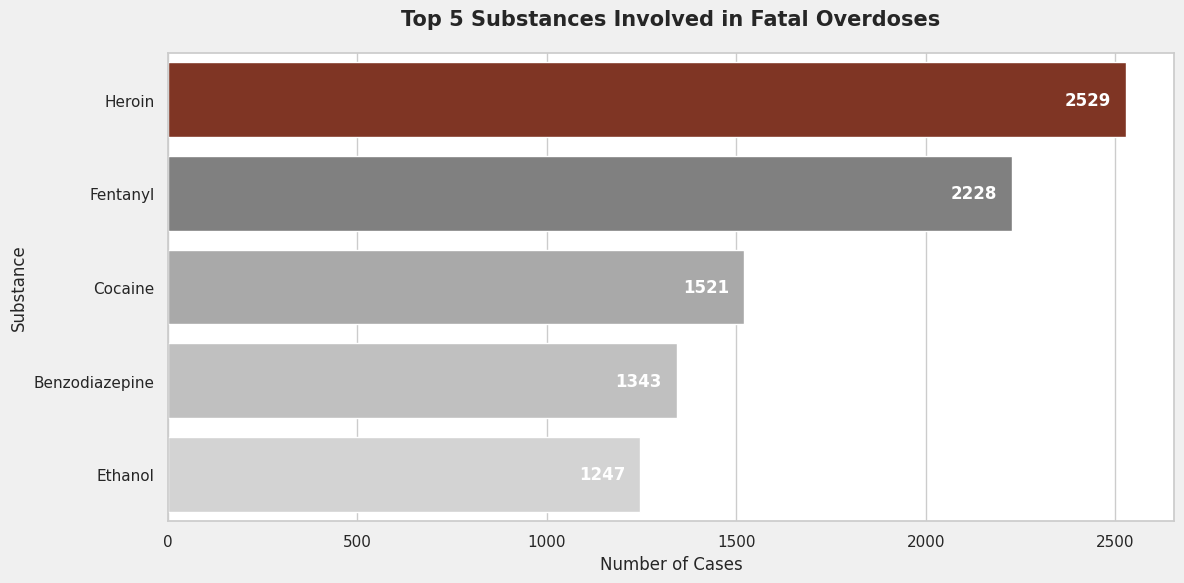

In [10]:
# --- GRAPHIC ---

plt.figure(figsize=(12, 6))

# Grayscale palette with burgundy highlight for Heroin
substance_colors = [
    color_burgund,  # Heroin (2529)
    '#808080',      # Fentanyl (2228)
    '#A9A9A9',      # Cocaine (1521)
    '#C0C0C0',      # Benzodiazepine (1343)
    '#D3D3D3'       # Ethanol (1247)
]

# Plot horizontal distribution
sns.barplot(x=top_substances.values, y=top_substances.index,
            palette=substance_colors, hue=top_substances.index, legend=False)

# Styling axis labels
plt.title("Top 5 Substances Involved in Fatal Overdoses",
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Number of Cases", fontsize=12)
plt.ylabel("Substance", fontsize=12)

# Add numeric labels inside bars for clarity
for i, v in enumerate(top_substances.values):
    plt.text(v - 40, i, f"{int(v)}", color='white', fontweight='bold',
             va='center', ha='right', fontsize=12)

plt.tight_layout()
plt.show()

# Insight: Heroin remains the single most dominant substance in the dataset (2529 cases)


### Heroin Combination Analysis

In [11]:
# --- ANALYSIS ---
# Define substances for co-occurrence analysis
combo_cols = ['AnyOpioid', 'Fentanyl', 'Cocaine', 'Ethanol', 'Benzodiazepine', 'Fentanyl_Analogue', 'Methadone']

# Filter heroin cases and calculate frequency
heroin_combos = (df_filled[df_filled['Heroin'] == 1][combo_cols]
                 .sum()
                 .sort_values(ascending=False))

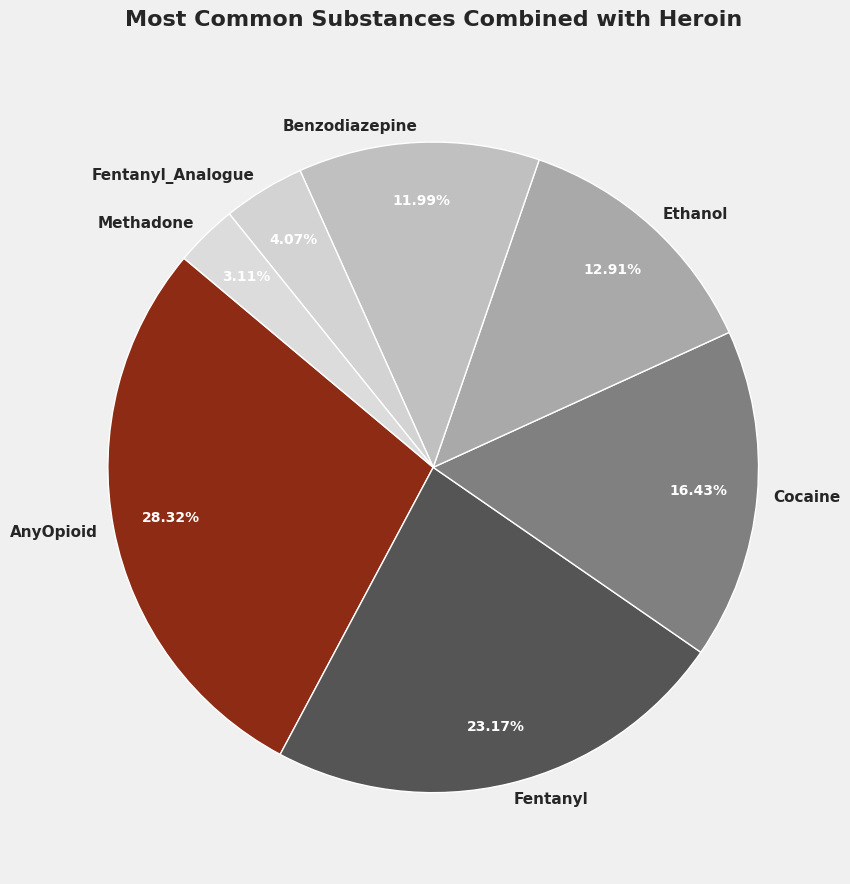

In [12]:
# --- GRAPHIC ---

# Chart size setup
plt.figure(figsize=(12, 9))

# Color palette: Burgundy focus for AnyOpioid
colors = [color_burgund, '#555555', '#808080', '#A9A9A9', '#C0C0C0', '#D3D3D3', '#DCDCDC']

# Generate pie chart with precise distribution
wedges, texts, autotexts = plt.pie(
    heroin_combos,
    labels=heroin_combos.index,
    autopct='%1.2f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.82,
    labeldistance=1.05,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
# Formatting data labels for readability
plt.setp(autotexts, color='white', size=10)

# Chart title
plt.title("Most Common Substances Combined with Heroin",
          fontsize=16, fontweight='bold', pad=25)

plt.tight_layout()
plt.show()

# --- INSIGHTS ---

# 1. Lethal Synergies: AnyOpioid (27.62%) and Fentanyl (22.6%) dominate heroin cases.
# 2. Risk Profile: Fentanyl Analogue is a distinct risk factor at 3.97%.


## Demographic Patterns

This section examines the distribution of overdoses across sex, race, and age groups to identify the most vulnerable populations.

### Sex/Race/Age group distribution  

In [13]:
# --- ANALYSIS ---

# Calculate percentage distributions
sex_dist = df_filled['Sex'].value_counts(normalize=True).mul(100).round(2)
race_dist = df_filled['Race'].value_counts(normalize=True).mul(100).round(2)
age_dist = df_filled['Age_group'].value_counts(normalize=True).mul(100).round(2)

display(sex_dist, race_dist, age_dist)

# Data cleaning for visualization
df_valid_sex = df_filled[df_filled['Sex'] != 'UNKNOWN']
df_valid_race = df_filled[df_filled['Race'] != 'UNKNOWN']
df_valid_age = df_filled[df_filled['Age_group'] != 'UNKNOWN']

# Aggregate and sort categories
sex_viz = df_valid_sex['Sex'].value_counts()
race_viz = df_valid_race['Race'].value_counts().head(5)
age_order = ['41-60', '21-40', '61+', '0-20']
age_viz = df_valid_age['Age_group'].value_counts().reindex(age_order).fillna(0)



,proportion
Sex,
M,73.91
F,25.95
UNKNOWN,0.14


,proportion
Race,
WHITE,78.43
"HISPANIC, WHITE",10.99
BLACK,8.48
UNKNOWN,0.71
"HISPANIC, BLACK",0.47
"ASIAN, OTHER",0.35
ASIAN INDIAN,0.27
OTHER,0.22
CHINESE,0.04


,proportion
Age_group,
41-60,47.05
21-40,44.98
61+,6.13
0-20,1.78
UNKNOWN,0.06


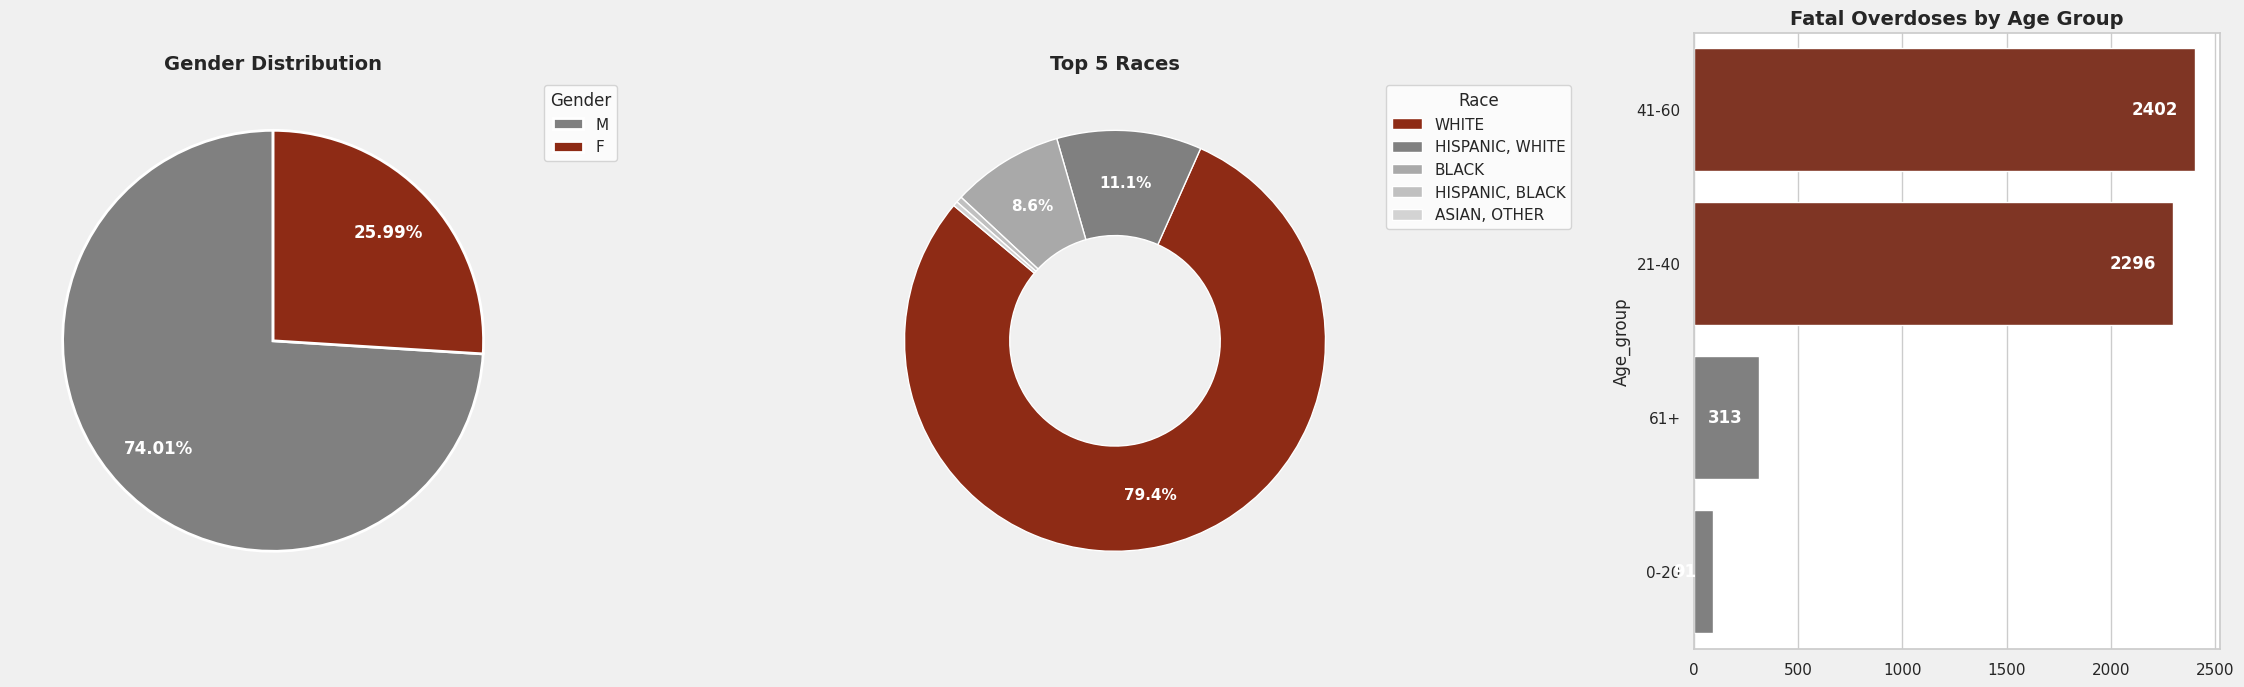

In [14]:
# --- GRAPHIC ---

# Layout setup
fig, axes = plt.subplots(1, 3, figsize=(26, 8))

# A. Gender Distribution (Pie Chart)
# Male: 76.04%, Female: 23.96%
axes[0].pie(sex_viz, labels=None, autopct='%1.2f%%', startangle=90,
            colors=[color_gray, color_burgund], pctdistance=0.75,
            wedgeprops={'edgecolor': 'w', 'linewidth': 2},
            textprops={'color':"w", 'weight':'bold', 'fontsize': 12})
axes[0].legend(sex_viz.index, title="Gender", loc="upper left", bbox_to_anchor=(1, 1))
axes[0].set_title("Gender Distribution", fontsize=14, fontweight='bold')

# B. Race Distribution (Donut Chart)
# White: 79.36%
axes[1].pie(race_viz, labels=None,
            autopct=lambda p: '{:.1f}%'.format(p) if p >= 1 else '',
            startangle=140,
            colors=[color_burgund, '#808080', '#A9A9A9', '#C0C0C0', '#D3D3D3'],
            pctdistance=0.75, wedgeprops={'width': 0.5, 'edgecolor': 'w'},
            textprops={'color':"w", 'weight':'bold', 'fontsize': 11})
axes[1].legend(race_viz.index, title="Race", loc="upper left", bbox_to_anchor=(1, 1))
axes[1].set_title("Top 5 Races", fontsize=14, fontweight='bold')

# C. Age Group Distribution (Horizontal Bar)
# High-risk highlight: 41-60 (4154 cases)
age_colors = [color_burgund if x in ['41-60', '21-40'] else color_gray for x in age_viz.index]
sns.barplot(x=age_viz.values, y=age_viz.index, ax=axes[2], palette=age_colors, hue=age_viz.index, legend=False)
axes[2].set_title("Fatal Overdoses by Age Group", fontsize=14, fontweight='bold')


# Internal data labels
for i, v in enumerate(age_viz.values):
    if v > 0:
        axes[2].text(v - 80, i, f"{int(v)}", color='white', fontweight='bold', va='center', ha='right')

plt.subplots_adjust(left=0.05, right=0.9, wspace=0.6)
plt.show()

# --- INSIGHTS ---

# 1. Gender Gap: Men account for 76.04% of total fatalities.
# 2. Racial Dominance: White individuals represent 79.36% of total fatalities.
# 3. Age Peak: The 41-60 demographic is the most affected (4154 cases).


### Gender-Based Prevalence of Key Toxicological Substances

In [15]:
# --- ANALYSIS ---

# Define target substances for comparative analysis
top_drugs = ['Heroin', 'Fentanyl', 'Cocaine', 'Benzodiazepine', 'Ethanol']

# Pivot data into long format for visualization
gender_melted = (df_filled[df_filled['Sex'].isin(['F', 'M'])]
                 .groupby('Sex')[top_drugs]
                 .sum()
                 .reset_index()
                 .melt(id_vars='Sex', var_name='Substance', value_name='Count'))

# Dynamic labeling for Heroin
h_labels = {0: str(gender_melted.loc[0, 'Count']), 5: str(gender_melted.loc[1, 'Count'])}

# Technical check
display(gender_melted)

,Sex,Substance,Count
0,F,Heroin,539
1,M,Heroin,1989
2,F,Fentanyl,465
3,M,Fentanyl,1758
4,F,Cocaine,381
5,M,Cocaine,1138
6,F,Benzodiazepine,463
7,M,Benzodiazepine,878
8,F,Ethanol,274
9,M,Ethanol,971


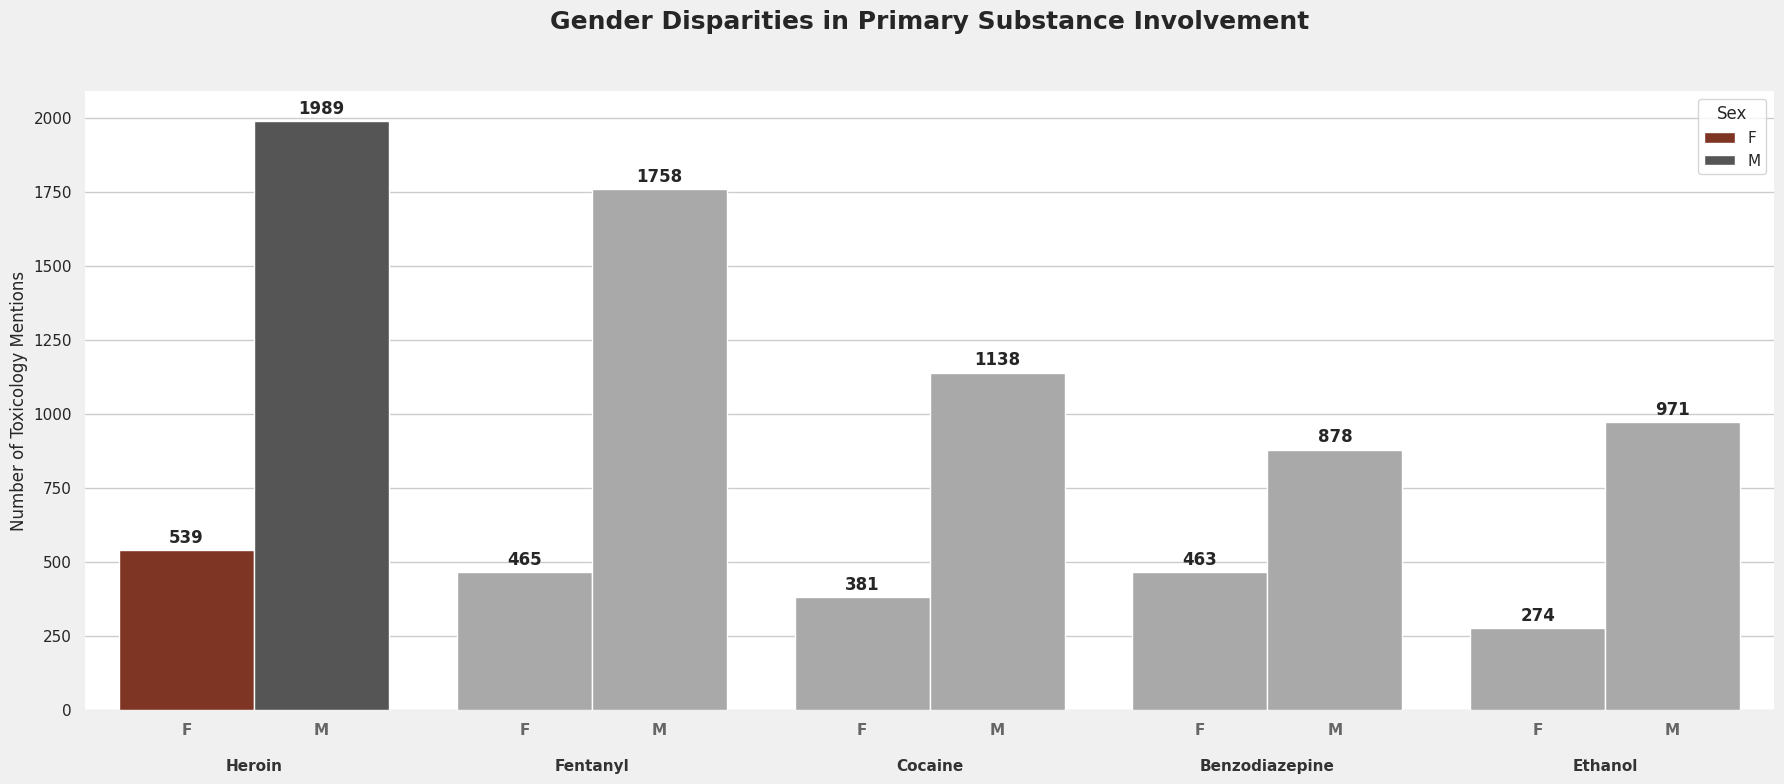

In [16]:
# --- GRAPHIC ---

plt.figure(figsize=(18, 8))

ax = sns.barplot(data=gender_melted, x='Substance', y='Count', hue='Sex',
                 palette={'F': color_burgund, 'M': '#555555'})

# Highlighting target substance and annotating bars
for i, bar in enumerate(ax.patches[:10]):
    val = int(bar.get_height())
    label = h_labels[i] if i in h_labels else val
    if i not in h_labels: bar.set_facecolor('#A9A9A9')
    ax.text(bar.get_x() + bar.get_width()/2, val + 25, label, ha='center', fontweight='bold')

# Custom axis styling
# Correctly extract bar centers by iterating through containers
bar_centers = sorted([b.get_x() + b.get_width()/2 for c in ax.containers for b in c])

ax.set_xticks(bar_centers)
ax.set_xticklabels(['F', 'M'] * len(top_drugs), fontweight='bold', color='#666666')
ax.set_xlabel("")

# Centering substance names below bar pairs
y_max = ax.get_ylim()[1]
substance_y_pos = -(y_max * 0.08)

sub_pos = [(bar_centers[i*2] + bar_centers[i*2+1])/2 for i in range(len(top_drugs))]
for i, drug in enumerate(top_drugs):
    ax.text(sub_pos[i], substance_y_pos, drug, ha='center', va='top',
            fontweight='bold', fontsize=11, rotation=0, color='#333333')

# Final formatting
plt.title("Gender Disparities in Primary Substance Involvement", fontsize=18, fontweight='bold', pad=45)
plt.ylabel("Number of Toxicology Mentions", fontsize=12)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# --- INSIGHT ---

# 1. Heroin remains the most frequently identified substance in toxicology reports for both genders.
#   It accounts for 1,989 mentions in males and 539 in females, making it the primary risk factor regardless of sex.
# 2. While males statistically dominate every category, females show a relatively high tendency for benzodiazepine involvement.
#   This category exhibits the narrowest gender disparity (878 males to 463 females), suggesting different consumption patterns compared to ethanol or cocaine.

### Substance Prevalence by Age Group

In [17]:
# --- ANALYSIS ---

# Aggregating by Age Group for all substances
# Filter out UNKNOWN and sum binary columns
age_map_data = df_filled[df_filled['Age_group'] != 'UNKNOWN']
age_substance_map = age_map_data.groupby('Age_group')[drug_cols].sum().astype(float)

# Reindexing to maintain logical age order
age_substance_map = age_substance_map.reindex(['41-60', '21-40', '61+', '0-20']).fillna(0)


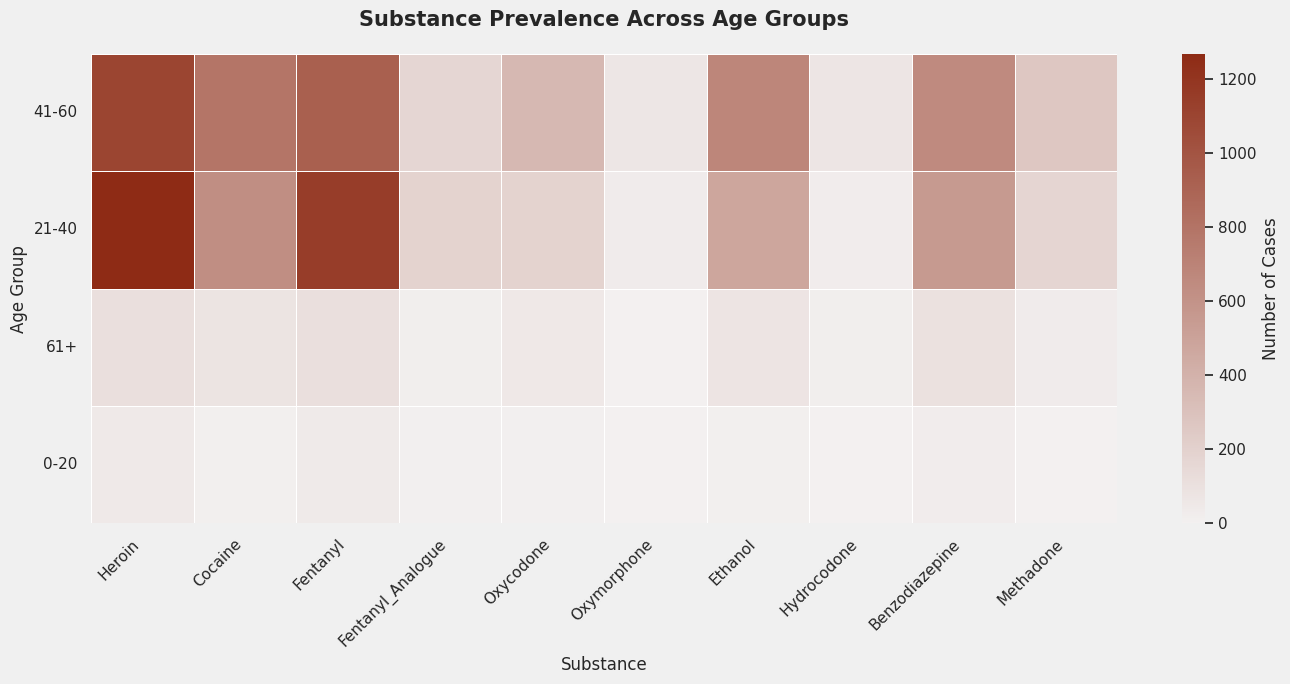

In [18]:
# --- GRAPHIC ---

plt.figure(figsize=(14, 7))

# Consistent burgundy styling
custom_cmap = sns.light_palette(color_burgund, as_cmap=True)

# Generate heatmap visualization
sns.heatmap(age_substance_map,
            annot=False,         # Numerical values removed for clarity
            cmap=custom_cmap,    # Professional palette
            linewidths=.5,       # Subtle separation of cells
            cbar_kws={'label': 'Number of Cases'})

# Professional styling and labels
plt.title("Substance Prevalence Across Age Groups", fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.xlabel("Substance", fontsize=12)
plt.ylabel("Age Group", fontsize=12)

plt.tight_layout()
plt.show()

# --- INSIGHTS ---

# 1. High-Volume Concentration: The 41-60 and 21-40 groups show the darkest intensity (4154 & 4088 cases).
# 2. Substance Shift: Younger victims (median 39) lean towards Fentanyl, while older victims (median 45) toward Ethanol.



## Yearly Trends & Substance Breakdown

In [19]:
# --- ANALYSIS ---

# 1. Substance Breakdown (Total mentions per year: 8,868)
substances = ['Benzodiazepine', 'Cocaine', 'Ethanol', 'Fentanyl', 'Heroin']
yearly_substances = df_filled.groupby('Year')[substances].sum()

# 2. Overall Case Trends (Unique fatal cases: 5,105)
unique_yearly_deaths = df_filled.groupby('Year').size()
total_unique_cases = df_filled.shape[0] # Dokładnie 5105

total_with_suma = pd.concat([unique_yearly_deaths, pd.Series({'Total': total_unique_cases})])


<Figure size 1600x700 with 0 Axes>

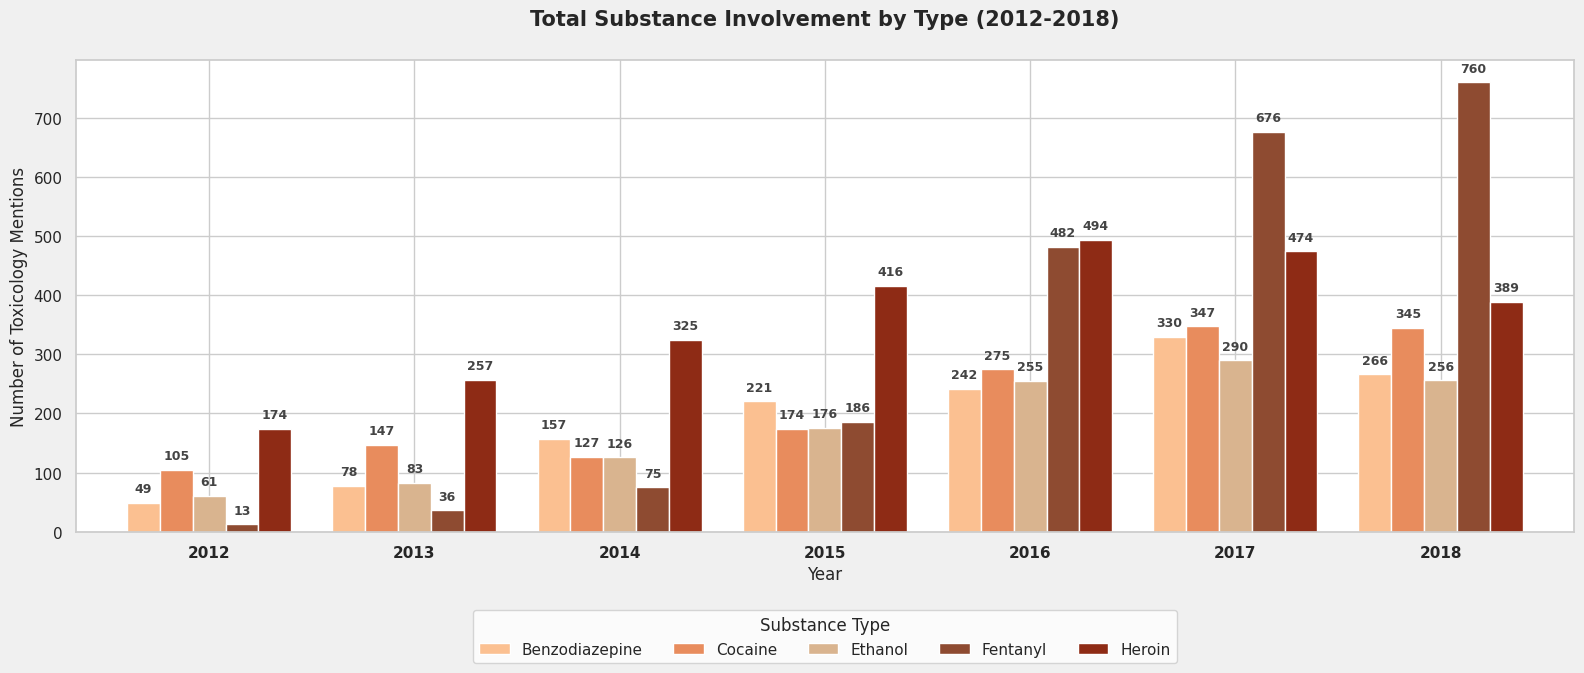

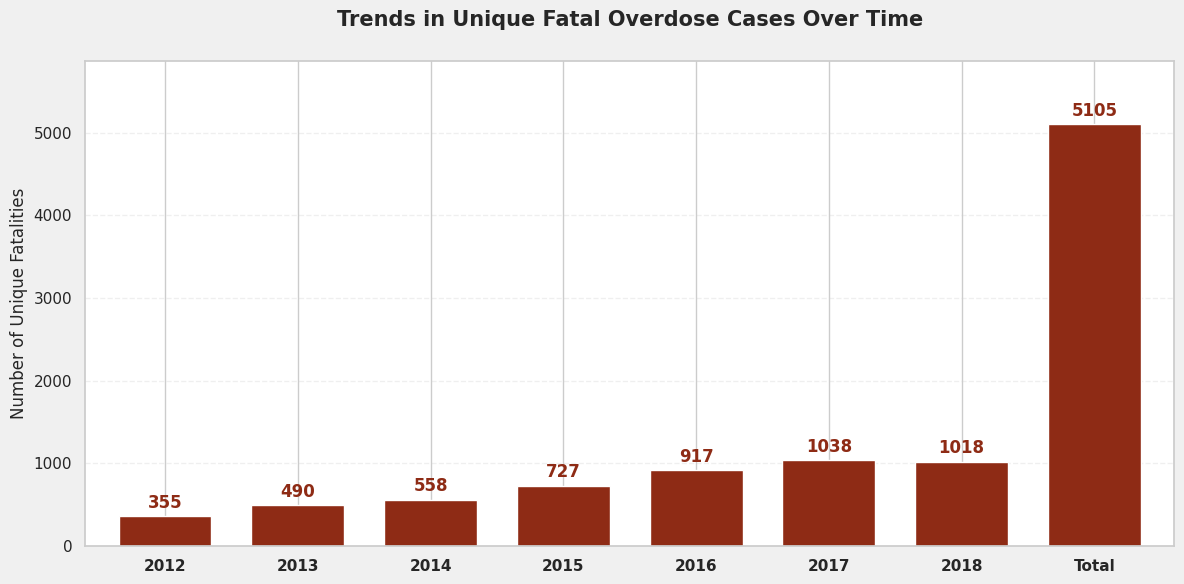

In [21]:
# --- GRAPHICS ---

# --- GRAPHIC 1: Substance Breakdown  ---
plt.figure(figsize=(16, 7))
ax1 = yearly_substances.plot(kind='bar', figsize=(16, 7), width=0.8,
                             color=['#FBC091', '#E88C5D', '#D9B48F', '#8E4B31', color_burgund],
                             edgecolor='white')

# Adding labels above grouped bars for clarity
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                     fontsize=9, fontweight='bold', color='#444444')

plt.title("Total Substance Involvement by Type (2012-2018)", fontsize=15, fontweight='bold', pad=25)
plt.legend(title="Substance Type", bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=5)
plt.xticks(rotation=0, fontweight='bold')
plt.ylabel("Number of Toxicology Mentions") # Rzetelny opis osi Y [Source 3]
plt.tight_layout()
plt.show()

# --- GRAPHIC 2: Overall Trends (Unique Fatal Cases) ---
plt.figure(figsize=(12, 6))

ax2 = total_with_suma.plot(kind='bar', color=color_burgund, width=0.7)

# Accurate data labels for unique deaths
for i, v in enumerate(total_with_suma):
    ax2.text(i, v + 100, str(int(v)), ha='center', fontweight='bold', fontsize=12, color=color_burgund)

plt.title("Trends in Unique Fatal Overdose Cases Over Time", fontsize=15, fontweight='bold', pad=25)
plt.xticks(rotation=0, fontweight='bold')
plt.ylabel("Number of Unique Fatalities")
plt.ylim(0, total_unique_cases * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# --- INSIGHTS ---
# 1. Data Integrity: The total number of unique fatal cases is 5,105.
# 2. Polydrug Pattern: Total substance mentions (8,868) exceed the number of cases,
#    highlighting that the average victim had ~1.7 substances in their system.
# 3. Peak Crisis: Unique fatalities peaked in 2017 with a significant surge in Fentanyl involvement.

In [22]:
#from google.colab import files

# Save DataFrame to Excel
df_filled.to_excel("cleaned_drug_deaths.xlsx", index=False)

# Download the file to your computer
files.download("cleaned_drug_deaths.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>